In [1]:
#librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import holidays as hld

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler #Para estandarizar
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
# carga del archivo
uber = pd.read_csv('uber_fares.csv')

## Analisis descriptivo

In [3]:
uber.info() #200000 registros

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Convertimos los datos de fecha, a su dato correspondiente

In [4]:
uber['date'] = pd.to_datetime(uber['date'])
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

In [5]:
uber.describe()

,key,date,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,2012-03-22 15:02:18.433115648,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
min,1.000000e+00,2009-01-01 01:15:22.000000600,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,2010-08-25 08:20:16,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,2012-03-21 20:44:29.500000256,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,2013-10-19 02:14:16.500000512,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,2015-06-30 23:40:39.000000100,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000
std,1.601382e+07,NaN,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997


### Creación de nuevas variables

In [6]:
def distancia(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))

In [21]:
uber["distancia"] = distancia(uber["pickup_latitude"], uber["pickup_longitude"], uber["dropoff_latitude"], uber["dropoff_longitude"])

uber["hora"] = uber["pickup_datetime"].dt.hour
uber["fecha"] = uber["pickup_datetime"].dt.date
uber["día"] = uber["pickup_datetime"].dt.day_name()
uber["num_dia"] = uber["pickup_datetime"].dt.weekday

us_holidays = hld.US()
us_holidays = hld.country_holidays('US')

nyse_holidays = hld.NYSE()
nyse_holidays = hld.financial_holidays('NYSE')

uber["feriado"] = uber["fecha"].apply(lambda x: x in us_holidays or x in nyse_holidays)

### Valores atipicos

In [8]:
precios_negativos_cero = uber[uber["fare_amount"] <= 0]
print(f"Viajes con costos negativos: {precios_negativos_cero["passenger_count"].count()}") # hay 17 valores negativos y 5 con valor 0

Viajes con costos negativos: 22


In [9]:
uber[((uber["pickup_longitude"] <= -180) | (uber["pickup_longitude"] >= 180)) |
    ((uber["dropoff_latitude"] <= -90) | (uber["dropoff_latitude"] >= 90)) |
    ((uber["pickup_latitude"] <= -90) | (uber["pickup_latitude"] >= 90)) |
    ((uber["dropoff_longitude"] <= -180) | (uber["dropoff_longitude"] >= 180))
    ]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia,hora,fecha,día,feriado
4949,42931506,2012-04-28 00:58:00.000000235,4.9,2012-04-28 00:58:00+00:00,-748.016667,40.739957,-74.003570,40.734192,1,2379.081331,0,2012-04-28,Saturday,False
32549,5634081,2012-06-16 10:04:00.000000610,15.7,2012-06-16 10:04:00+00:00,-74.016055,40.715155,-737.916665,40.697862,2,2885.814182,10,2012-06-16,Saturday,False
48506,1055960,2011-11-05 23:26:00.000000309,33.7,2011-11-05 23:26:00+00:00,-735.200000,40.770092,-73.980187,40.765530,1,3015.112108,23,2011-11-05,Saturday,False
56617,14257861,2012-03-11 07:24:00.000000310,8.1,2012-03-11 07:24:00+00:00,-73.960828,404.433332,-73.988357,40.769037,1,253.182192,7,2012-03-11,Sunday,False
61793,2849369,2012-06-13 05:45:00.000000600,8.5,2012-06-13 05:45:00+00:00,-73.951385,401.066667,-73.982110,40.754117,1,21.654631,5,2012-06-13,Wednesday,False
75851,33249845,2011-11-05 00:22:00.000000510,15.7,2011-11-05 00:22:00+00:00,-1340.648410,1644.421482,-3356.666300,872.697628,1,10196.228613,0,2011-11-05,Saturday,False
91422,23566642,2011-05-18 13:24:00.000000213,16.1,2011-05-18 13:24:00+00:00,57.418457,1292.016128,1153.572603,-881.985513,1,1396.154787,13,2011-05-18,Wednesday,False
103745,16826862,2011-10-14 19:04:00.000000202,12.9,2011-10-14 19:04:00+00:00,-736.216667,40.767035,-73.982377,40.725562,1,2966.236350,19,2011-10-14,Friday,False
139447,39981694,2012-01-20 11:50:00.000000880,13.7,2012-01-20 11:50:00+00:00,-74.011042,40.709780,-73.983163,493.533332,4,6413.487601,11,2012-01-20,Friday,False
144253,9421322,2009-08-26 11:55:00.000000230,7.3,2009-08-26 11:55:00+00:00,-768.550000,40.757812,-73.997040,40.740007,1,1327.276030,11,2009-08-26,Wednesday,False


In [10]:
""""
Reemplazamos los valores de las columnas de latitud y longitud que son 0 por NaN
"""
uber['pickup_latitude'] = uber['pickup_latitude'].replace(0, np.nan)
uber['pickup_longitude'] = uber['pickup_longitude'].replace(0, np.nan)
uber['dropoff_latitude'] = uber['dropoff_latitude'].replace(0, np.nan)
uber['dropoff_longitude'] = uber['dropoff_longitude'].replace(0, np.nan)

"""
Reemplazamos los valores fuera del rango de latitud y longitud
"""
uber.loc[
    ((uber["pickup_longitude"] <= -180) | (uber["pickup_longitude"] >= 180)) |
    ((uber["dropoff_latitude"] <= -90) | (uber["dropoff_latitude"] >= 90)) |
    ((uber["pickup_latitude"] <= -90) | (uber["pickup_latitude"] >= 90)) |
    ((uber["dropoff_longitude"] <= -180) | (uber["dropoff_longitude"] >= 180)),
    ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]
] = np.nan

# Reemplzamos donde la distancia sea 0, o valores atipico por nulos
uber['distancia'] = uber['distancia'].apply(lambda x: np.nan if x <= 0 else x)

q1 = uber["distancia"].quantile(0.25)
q3 = uber["distancia"].quantile(0.75)

iqr = q3 - q1
limite_inferior = max(q1 - 1.5 * iqr,0)
limite_superior = q3 + 1.5 * iqr

uber['distancia'] = uber['distancia'].apply(lambda x: np.nan if x < limite_inferior or x > limite_superior else x)
uber.loc[uber['distancia'].isna(), ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']] = np.nan

# eliminamos con costos menores o iguales que 0
uber = uber[
    (uber["fare_amount"] > 0)
]

# Reemplamos el valor atipico del precio, por NaN

# uber['fare_amount'] = uber['fare_amount'].replace(uber['fare_amount'].max(), np.nan)

In [11]:
porcentaje_eliminados = round((200000- len(uber)) / 200000 * 100, 2)
print(f"Se eliminaron el {porcentaje_eliminados}% de los datos")

Se eliminaron el 0.01% de los datos


### Valores Nulos

In [12]:
uber.isna().sum()

key                      0
date                     0
fare_amount              0
pickup_datetime          0
pickup_longitude     22013
pickup_latitude      22013
dropoff_longitude    22013
dropoff_latitude     22013
passenger_count          0
distancia            22013
hora                     0
fecha                    0
día                      0
feriado                  0
dtype: int64

In [13]:
# Reemplazo los valores por knn
columnas_a_imputar = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude','distancia']

imputer = KNNImputer(n_neighbors=5)

uber[columnas_a_imputar] = imputer.fit_transform(uber[columnas_a_imputar])

### Graficos

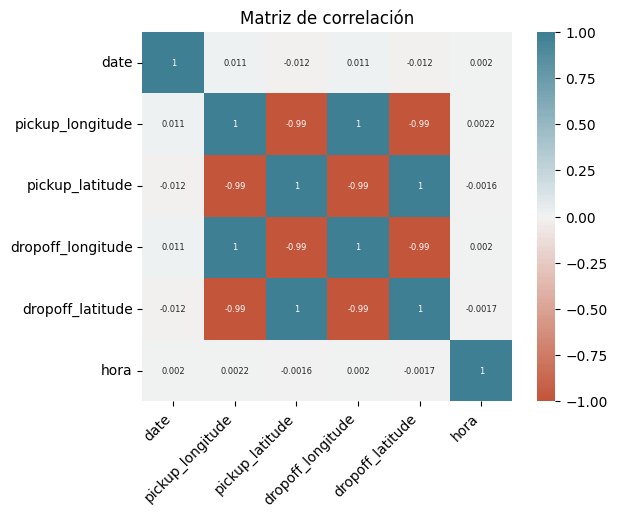

In [14]:
columnas_sin_corr = ["fare_amount", "passenger_count", "distancia", "día", "feriado","key","fecha","pickup_datetime"]
matriz = uber.drop(columns=columnas_sin_corr)
corr = matriz.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title("Matriz de correlación")
plt.show()

### Estandarización y division del dataset

In [23]:
columnas_cualitativas = ["passenger_count","distancia"]
scaler = StandardScaler().set_output(transform="pandas")
X_estandarizado = scaler.fit_transform(uber[columnas_cualitativas])
X_estandarizado["feriado"] = uber["feriado"]
X_estandarizado["dia"] = uber["num_dia"]
X_estandarizado["hora"] = uber["hora"]
y = uber["fare_amount"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_estandarizado, y, test_size=0.2, random_state=42)

## Modelos de regresión

### Regresión lineal
$$
\text{fare\_amount} = 11.69 + 0.099 \cdot \text{passenger\_count} + 0.542 \cdot \text{distancia} - 0.0077 \cdot \text{feriado} + 0.0247 \cdot \text{dia} - 0.0311 \cdot \text{hora}
$$

In [30]:
X_train.columns

Index(['passenger_count', 'distancia', 'feriado', 'dia', 'hora'], dtype='object')

In [25]:
modelo = LinearRegression().fit(X_train,y_train)

In [31]:
modelo.coef_

array([ 0.09932973,  0.54237356, -0.00771559,  0.02468984, -0.03105436])

In [32]:
modelo.intercept_

np.float64(11.694900186802235)